In [ ]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt

import sys
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
%matplotlib widget 

In [ ]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
#run = 104 #XAS step mono
#run = 119 #waveplate
#run = 151 #fixed energy
#run = 76 #XAS fly mono

bgrun = 191
# run = 10
runs=[178,179,180,181,182,183,184,185,186,188]
run=178

#exp = 'rix100836924'
# exp = 'rix101265125'
# exp = 'rix101331225' #HBQ
exp = 'rix101231825' #FeRuFe
#79,81,82,83,85,94,95,96,98


fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = './roi_input_ferufe.yml'
bgyaml = './roi_input.yml'
data = SmallData(fname,fyaml)
bg = SmallData(bgname, bgyaml)


for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True,scantype='mono_fly')


avg=avg_data(runs,proc_folder)


accessing intgrp
accessing epics
initialising <HDF5 group "/intg/axis_svls" (98 members)>
setting up properties
accessing scan variable
scanvariable unknown
loadingcount
loadingdroplet_dense_curve_corr_pj_ax_1_data
loadingtiming_sum_eventcodes
loadingdet_rix_fim0_sum_full_area
loadingdet_rix_fim1_sum_full_area
apds does not exits 
loadingdet_rix_fim0_sum_full_area
loadingdet_rix_fim1_sum_full_area
accessing intgrp
accessing epics
initialising <HDF5 group "/intg/axis_svls" (98 members)>
setting up properties
accessing scan variable


TypeError: asarray() missing required argument 'a' (pos 0)

In [3]:
run

188

In [4]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
#run = 104 #XAS step mono
#
bgrun = 191
# run = 10
runs=[178,179,180,181,182,183,184,185,186,188]
run=178

#exp = 'rix100836924'
# exp = 'rix101265125'
# exp = 'rix101331225' #HBQ
exp = 'rix101231825' #FeRuFe
#79,81,82,83,85,94,95,96,98


fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = './roi_input_ferufe.yml'
bgyaml = './BGroi_input.yml'
# data = SmallData(fname,fyaml)
# bg = SmallData(bgname, bgyaml)

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0086.h5'

test = h5py.File(fname,'r') #as file:
    # print(file['epics_archiver'].keys())

In [7]:
test['intg'].values()

ValuesViewHDF5(<HDF5 group "/intg" (2 members)>)

In [22]:
import yaml
with open('roi_input_ferufe.yml','r') as file:
    ferufe=yaml.safe_load(file)

len(ferufe['mono_calib'])

3

loadingdroplet_dense_curve_corr_pj_ax_1_data


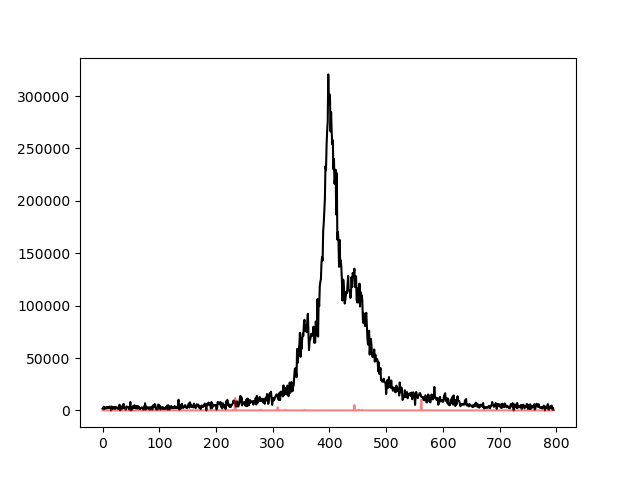

In [14]:
fig,ax=plt.subplots()
ax.plot(np.nansum(red.data.integrating.axis_svls.full_area,axis=0),'k')
ax.plot(np.nansum(red.bg.integrating.axis_svls.full_area,axis=0),'r',alpha=0.5)
# ax.plot(np.nansum(red.data.svls,axis=0),'k')
# ax.plot(np.nansum(red.bg.svls,axis=0),'r')

(696.6730769230769, 709.8269230769231)

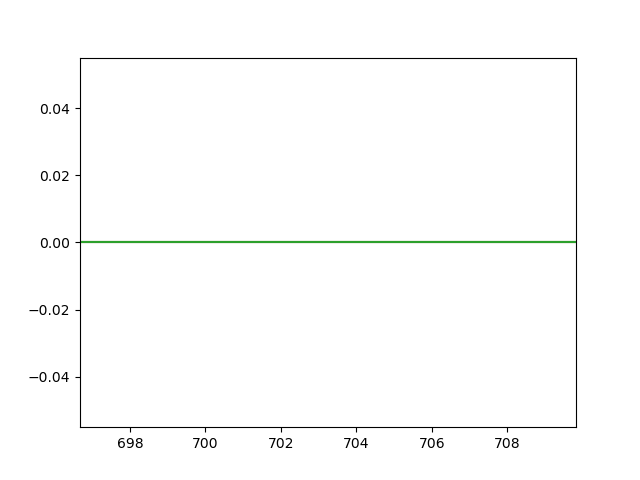

In [3]:
fig,ax=plt.subplots(1,1)
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1)-np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_off,np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1))
ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])

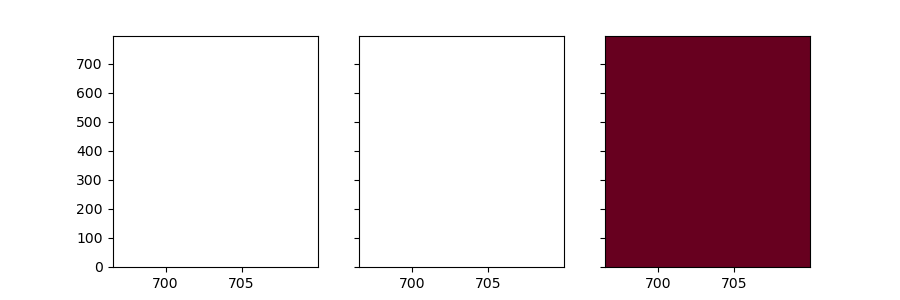

In [4]:
fig,ax=plt.subplots(1,3,figsize=(9,3),sharex=True,sharey=True)
dmax=np.nanmax(avg['axis_svls_off_mean'])/10
ax[0].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_mean'].shape[1]),avg['axis_svls_on_mean'].T,cmap='terrain_r',vmin=0,vmax=dmax)
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_mean'].shape[1]),avg['axis_svls_off_mean'].T,cmap='terrain_r',vmin=0,vmax=dmax)
ddat=np.nanmax(np.abs(avg['axis_svls_on_mean']-avg['axis_svls_off_mean']))
ax[2].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_mean'].shape[1]),(avg['axis_svls_on_mean']-avg['axis_svls_off_mean']).T,cmap='RdBu')
# ax[0].set_xlim([avg['scanvar_off'].min(),avg['scanvar_off'].max()])

(696.6730769230769, 709.8269230769231)

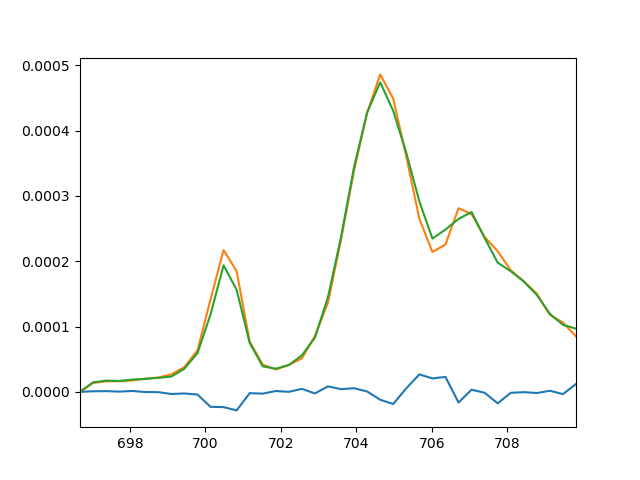

In [9]:
fig,ax=plt.subplots(1,1)
ax.plot(avg['scanvar_on'],np.sum(avg['axis_svls_on_mean'],1)-np.sum(avg['axis_svls_off_mean'],1))
ax.plot(red.scanvar_off,np.sum(avg['axis_svls_off_mean'],1))
ax.plot(avg['scanvar_on'],np.sum(avg['axis_svls_on_mean'],1))
ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])


In [8]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

# if emi_calib == []:
#     if data.runinfo == 'mono':
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            dat=avg['axis_svls_sum'], 
            mono = avg['scanvar'], 
            calib=emi_calib, 
                points = points)
#     else:
#         print('need mono scan to calibrate using emission axis')
# else:
#     emi,calib =pixel2emi(np.arange(avg['axis_svls_sum'].shape[1]), mono=[],
#                     dat=avg['axis_svls_sum'], 
#                     calib=emi_calib) 
                    
# if data.runinfo == 'mono':
mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
# else:
#     E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

KeyError: 'axis_svls_sum'

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

if emi_calib == []:
    if data.scantype == 'mono':
        emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    mono = avg['scanvar_on'], 
                    calib=emi_calib, 
                    points = points)
    else:
        print('need mono scan to calibrate using emission axis')
else:
    emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    calib=emi_calib) 
                    
if data.scantype == 'mono':
    mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
    mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)
else:
    E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

<KeysViewHDF5 ['Sums', 'epics_archiver', 'intg', 'scan', 'timestamp', 'timing']>


UnboundLocalError: cannot access local variable 'scantype' where it is not associated with a value

In [1]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



NameError: name 'plt' is not defined

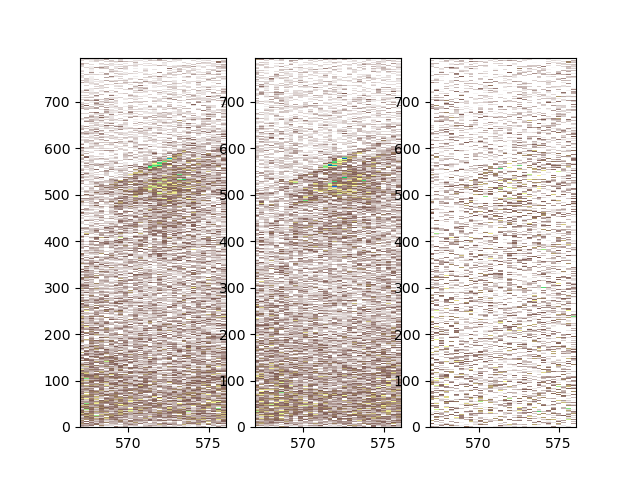

In [4]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [5]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=310
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['andor_vls']['scan_sum_lxt_ttc']
# test1['scan']['lxt_ttc']

<HDF5 dataset "scan_sum_lxt_ttc": shape (16292, 1), type "<f8">

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

['/epics_archiver/SP1K1_MONO_MMS_M_PI.RBV']


In [1]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

NameError: name 'h5py' is not defined

In [8]:
runs=[399,400]
avg = {}
with h5py.File(f'./proc/Run{runs[0]:04d}.h5','r') as tmp:
    keys = list(tmp.keys())
    for key in keys:
        avg[key] = np.zeros(tmp[key].shape)

i=0
for run in runs:
    i=i+1
    file = f'./proc/Run{run:04d}.h5'
    for key in keys:    
        with h5py.File(file,'r') as f:
            # print(f.keys())
            if avg[key].shape==f[key].shape:
                avg[key] = avg[key] + f[key]
            else:
                print(f'Run {run} shapes do not match')
for key in keys:
    avg[key] = avg[key]/i



In [11]:
avg['scanvar_on']

array([567.13565063, 567.43847656, 567.74136353, 568.04421997,
       568.34707642, 568.64996338, 568.95281982, 569.25567627,
       569.55853271, 569.86141968, 570.16427612, 570.46710205,
       570.76998901, 571.07284546, 571.3757019 , 571.67855835,
       571.98144531, 572.28430176, 572.5871582 , 572.89004517,
       573.19290161, 573.49572754, 573.79858398, 574.10147095,
       574.40432739, 574.70718384, 575.01004028, 575.31292725,
       575.61578369, 575.91864014])

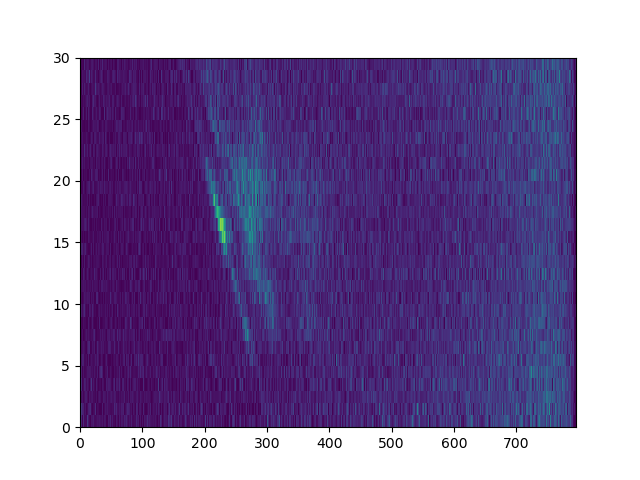

In [18]:
fig,ax=plt.subplots(1,1)
ax.pcolor(avg['axis_svls_off_mean'])

In [ ]:
def average_data_test(datas, detector):
    averaged_data = {}
    
    if detector not in datas[0]:
        raise ValueError(f"Detector '{detector}' not found")
    is_nested_structure = isinstance(datas[0][detector], dict) and ('on' in datas[0][detector] or 'off' in datas[0][detector])
    if not is_nested_structure:
        all_values = []
        
        #determine the shape
        shapes = []
        for data in datas:
            if detector in data:
                shapes.append(np.shape(data[detector]))
        homogeneous_shape = all(shape == shapes[0] for shape in shapes)
        if homogeneous_shape:
            for data in datas:
                if detector in data:
                    all_values.append(data[detector])
            
            all_values = np.array(all_values)
            
            averaged_data['mean'] = np.nanmean(all_values, axis=0)
            averaged_data['std'] = np.nanstd(all_values, axis=0)
            
            #std error
            n_runs = len(all_values)
            if n_runs > 1:
                averaged_data['std_err'] = averaged_data['std'] / np.sqrt(n_runs)
            else:
                averaged_data['std_err'] = np.zeros_like(averaged_data['mean'])
        else:
            print(f"Warning: {detector} has inconsistent shapes across runs. Using only the first run.")
            averaged_data['mean'] = datas[0][detector]
            averaged_data['std'] = np.zeros_like(datas[0][detector])
            averaged_data['std_err'] = np.zeros_like(datas[0][detector])
        
        return averaged_data
    
    # Handle nested structure with on/off
    has_pump_probe = 'on' in datas[0][detector]
    
    # Initialize data collection arrays
    var_off_mean = []
    var_off_std = []
    var_off_sum = []
    frames_per_bin_off = []
    
    if has_pump_probe:
        var_on_mean = []
        var_on_std = []
        var_on_sum = []
        frames_per_bin_on = []
    
    # Collect data from all runs
    for data in datas:
        if detector not in data:
            continue
        
        # Collect 'off' data
        if 'off' in data[detector]:
            var_off_mean.append(data[detector]['off']['mean'])
            var_off_std.append(data[detector]['off']['std'])
            if 'sum' in data[detector]['off']:
                var_off_sum.append(data[detector]['off']['sum'])
            frames_per_bin_off.append(data['frames_per_bin']['off'])
        
        # Collect 'on' data if available
        if has_pump_probe and 'on' in data[detector]:
            var_on_mean.append(data[detector]['on']['mean'])
            var_on_std.append(data[detector]['on']['std'])
            if 'sum' in data[detector]['on']:
                var_on_sum.append(data[detector]['on']['sum'])
            frames_per_bin_on.append(data['frames_per_bin']['on'])
    
    # Process 'off' data
    if var_off_mean:
        # Check if all arrays have the same shape
        shapes = [np.shape(arr) for arr in var_off_mean]
        homogeneous_shape = all(shape == shapes[0] for shape in shapes)
        
        averaged_data['off'] = {}
        
        if homogeneous_shape:
            var_off_mean = np.array(var_off_mean)
            var_off_std = np.array(var_off_std)
            frames_per_bin_off = np.array(frames_per_bin_off)
            
            averaged_data['off']['mean'] = np.nanmean(var_off_mean, axis=0)
            averaged_data['off']['std'] = np.nanstd(var_off_mean, axis=0)
            if var_off_sum:
                var_off_sum = np.array(var_off_sum)
                averaged_data['off']['sum'] = np.nansum(var_off_sum, axis=0)
            
            n_runs = len(var_off_mean)
            averaged_data['off']['std_err'] = averaged_data['off']['std'] / np.sqrt(n_runs)
        else:
            print(f"Warning: {detector} 'off' has inconsistent shapes across runs. Using only the first run.")
            averaged_data['off']['mean'] = var_off_mean[0]
            averaged_data['off']['std'] = var_off_std[0]
            if var_off_sum:
                averaged_data['off']['sum'] = var_off_sum[0]
            averaged_data['off']['std_err'] = var_off_std[0] / np.sqrt(frames_per_bin_off[0])
    
    if has_pump_probe and var_on_mean:
        shapes = [np.shape(arr) for arr in var_on_mean]
        homogeneous_shape = all(shape == shapes[0] for shape in shapes)
        
        averaged_data['on'] = {}
        
        if homogeneous_shape:
            var_on_mean = np.array(var_on_mean)
            var_on_std = np.array(var_on_std)
            frames_per_bin_on = np.array(frames_per_bin_on)
            
            averaged_data['on']['mean'] = np.nanmean(var_on_mean, axis=0)
            averaged_data['on']['std'] = np.nanstd(var_on_mean, axis=0)
            
            if var_on_sum:
                var_on_sum = np.array(var_on_sum)
                averaged_data['on']['sum'] = np.nansum(var_on_sum, axis=0)
            
            n_runs = len(var_on_mean)
            averaged_data['on']['std_err'] = averaged_data['on']['std'] / np.sqrt(n_runs)
        else:
            print(f"Warning: {detector} 'on' has inconsistent shapes across runs. Using only the first run.")
            averaged_data['on']['mean'] = var_on_mean[0]
            averaged_data['on']['std'] = var_on_std[0]
            if var_on_sum:
                averaged_data['on']['sum'] = var_on_sum[0]
            averaged_data['on']['std_err'] = var_on_std[0] / np.sqrt(frames_per_bin_on[0])
    
    return averaged_data

['andor_vls_off_mean',
 'andor_vls_off_std',
 'andor_vls_off_sum',
 'andor_vls_on_mean',
 'andor_vls_on_std',
 'andor_vls_on_sum',
 'axis_svls_off_mean',
 'axis_svls_off_std',
 'axis_svls_off_sum',
 'axis_svls_on_mean',
 'axis_svls_on_std',
 'axis_svls_on_sum',
 'scanvar_off',
 'scanvar_on']